## 가중치 초기화, 어떻게 할 것인가?

정규분포식: $N(\mu, \sigma^2)$. $N(0, 1)$, 즉 평균이 0이고 표준편차가 1이면 표준 정규분포이고, 여기서 시그마값이 커질 수록 넓게 퍼지게 된다.

<br>

> As mentioned in Andy Jones’ post on Xavier Initialization: If the weights in a network start too small, then the signal shrinks as it passes through each layer until it’s too tiny to be useful.

+ 너무 값이 작아지면, 안되겠네. 그럼 표준편차가 $\sqrt\frac{4}{n}$인 경우는 사용하기 어렵겠다
+ Relu, leaky Relu의 경우 0에 많은 값들이 몰려있는데, 이 역시 불균형. 아마 


In [3]:
# coding: utf-8
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)

def leaky_ReLU(x):
    return np.maximum(0.01*x, x)


def tanh(x):
    return np.tanh(x)

node_num = 100  # 각 은닉층의 노드(뉴런) 수
hidden_layer_size = 10  # 은닉층이 5개
activations = {}  # 이곳에 활성화 결과를 저장

np.random.seed(42)
def experiment(init_key, activation_key):
    for i in range(hidden_layer_size):
        
        x = np.random.randn(1000, 100)
        
        if i != 0:
            x = activations[i-1]
            
        initializer = initializers[init_key]
        activation_function = activation_functions[activation_key]
        w = initializer
        a = np.dot(x, w)

        z = activation_function(a)

        activations[i] = z

    # 히스토그램 그리기
    for i, a in activations.items():
        plt.subplot(1, len(activations), i+1)
        # plt.title(str(i+1) + "-layer")
        if i != 0:
            plt.yticks([], [])
        # plt.xlim(0.1, 1)
        # plt.ylim(0, 7000)
        plt.hist(a.flatten(), 30, range=(-1, 1))

    plt.suptitle(f'{init_key}-{activation_key}')
    plt.savefig(f'{init_key}-{activation_key}.png')
    plt.show()


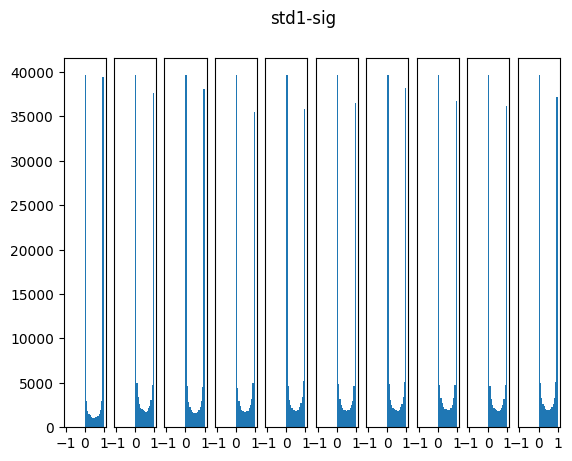

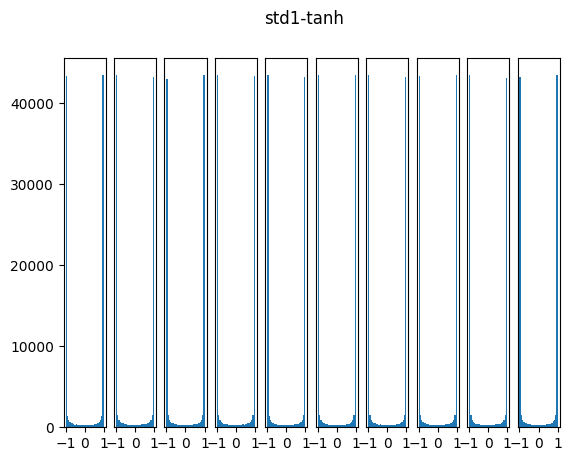

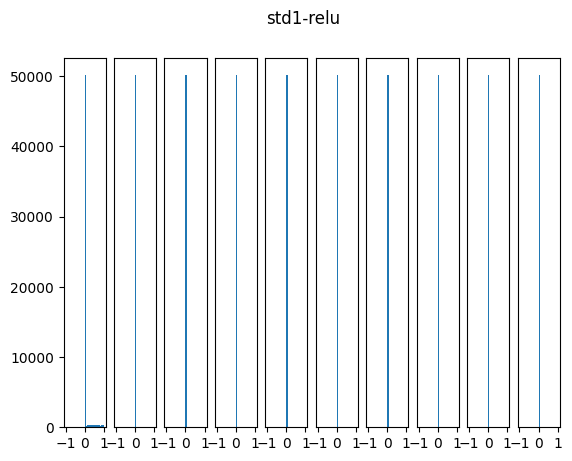

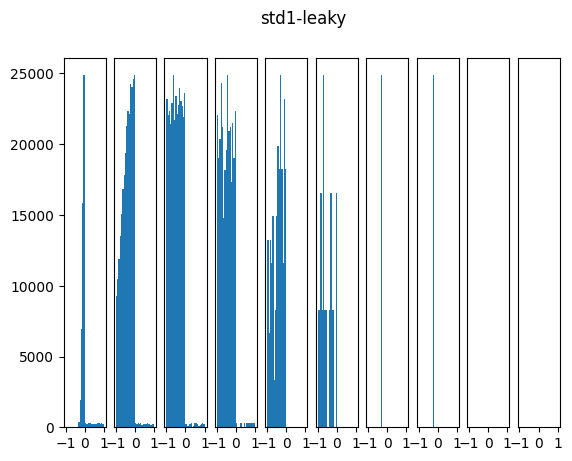

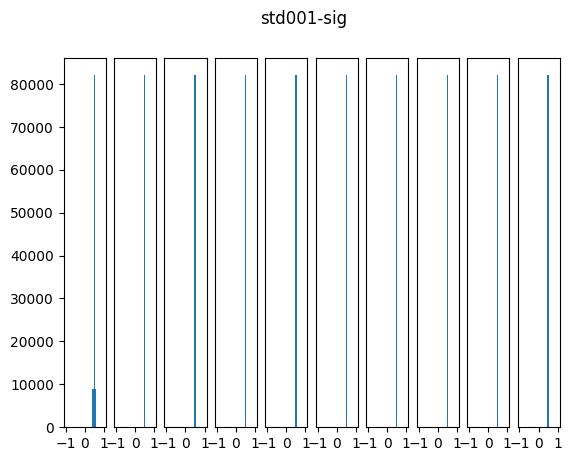

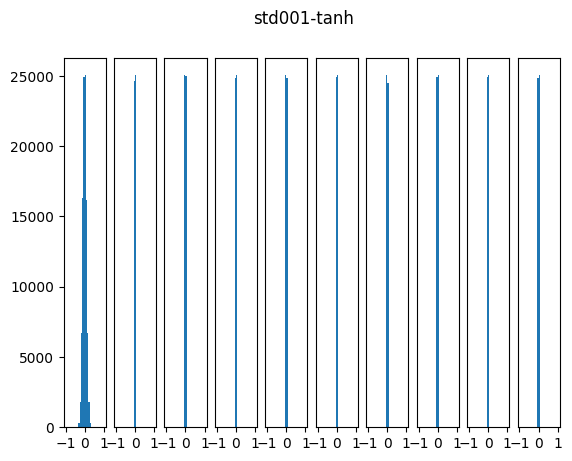

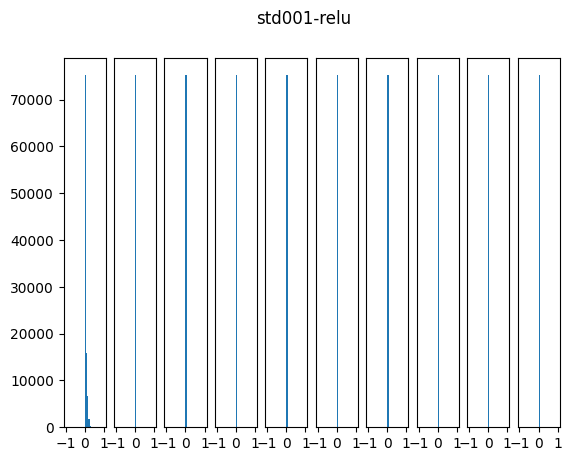

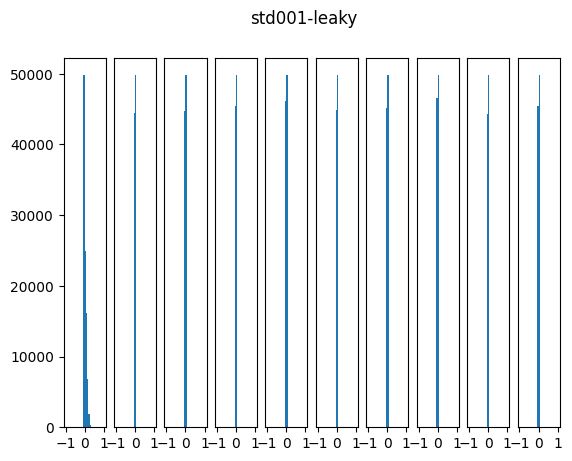

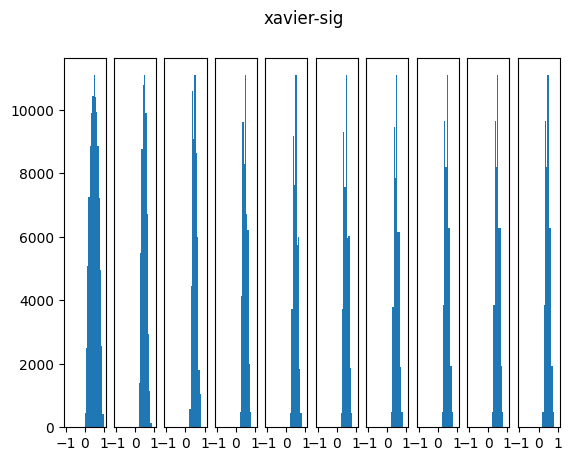

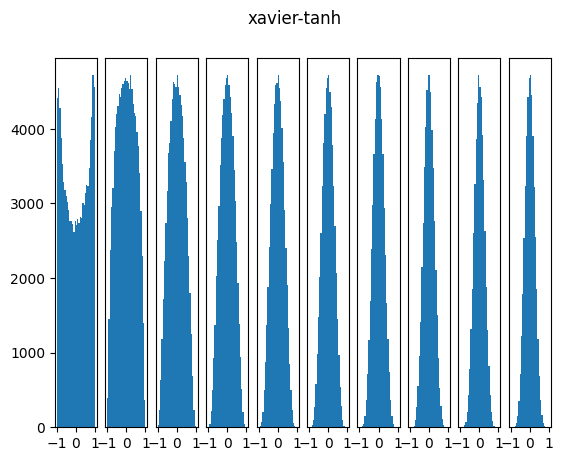

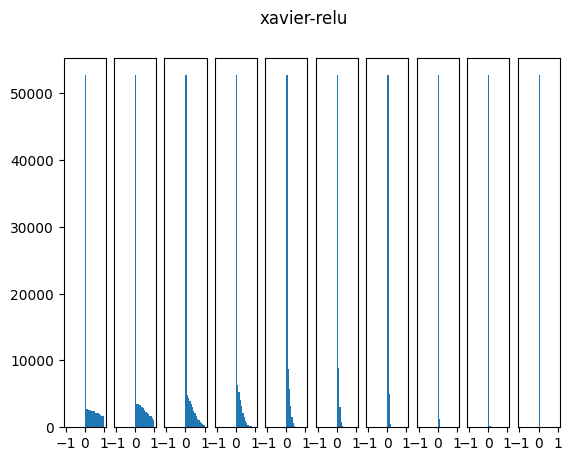

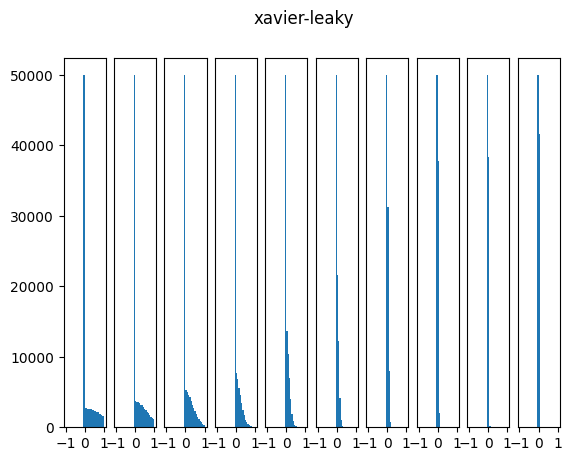

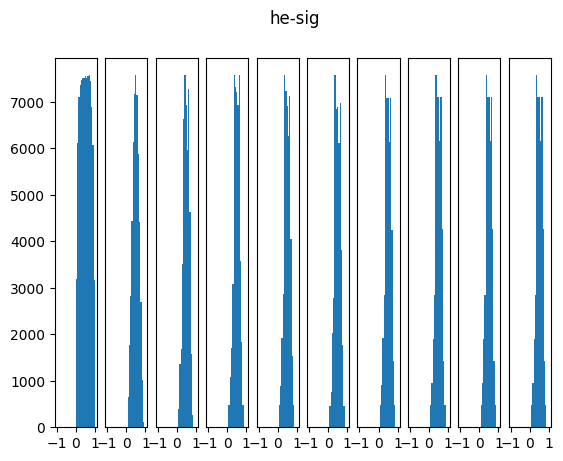

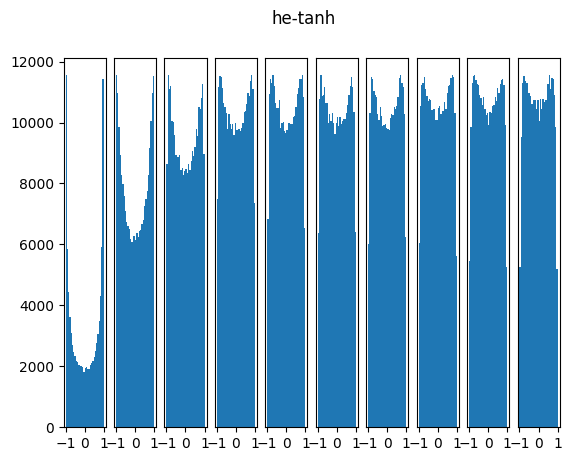

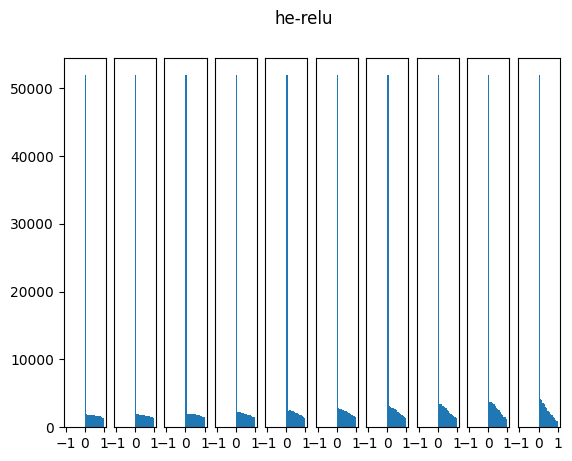

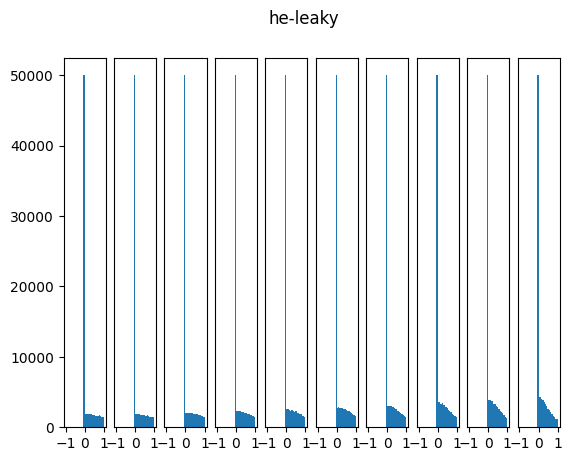

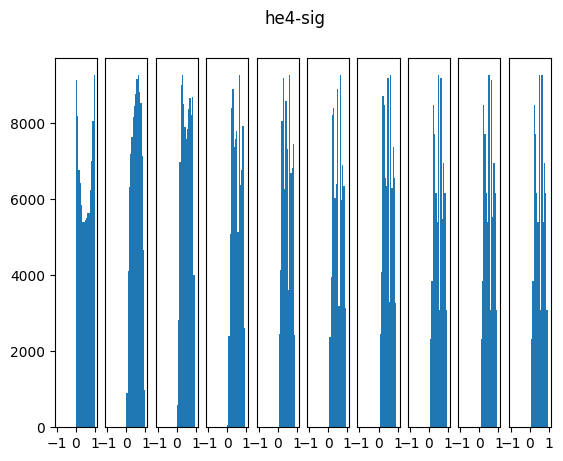

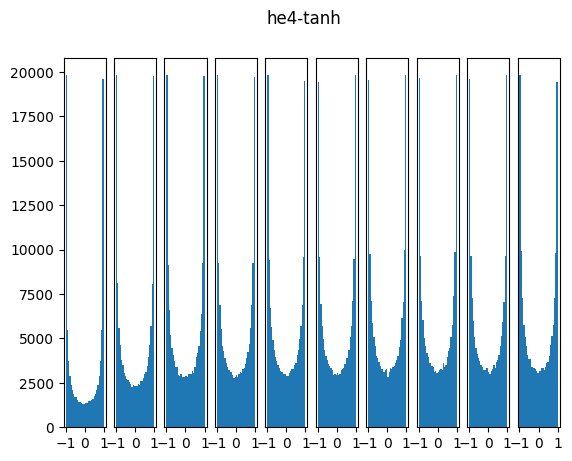

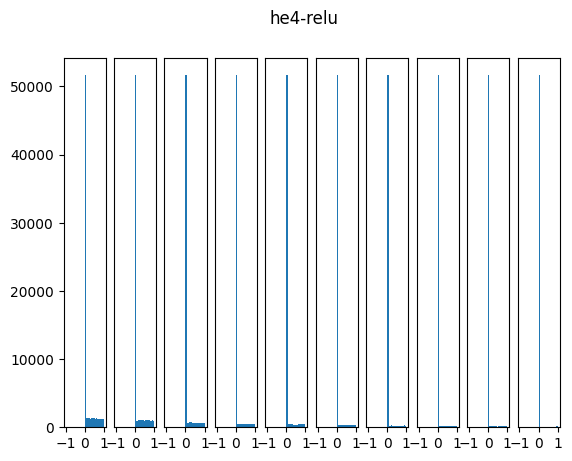

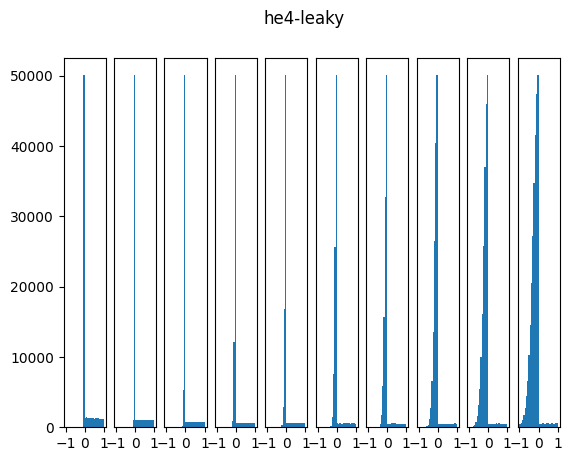

In [4]:
initializers = {'std1': np.random.randn(node_num, node_num) * 1,
                'std001': np.random.randn(node_num, node_num) * 0.01,
                'xavier': np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num),
                'he': np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num),
                'he4': np.random.randn(node_num, node_num) * np.sqrt(4.0 / node_num),
        }

activation_functions = {'sig':sigmoid,
                        'tanh':tanh,
                        'relu':ReLU,
                        'leaky':leaky_ReLU,
                        }



for initializer_key in initializers.keys():
        for activation_function_key in activation_functions.keys():
                experiment(initializer_key, activation_function_key)